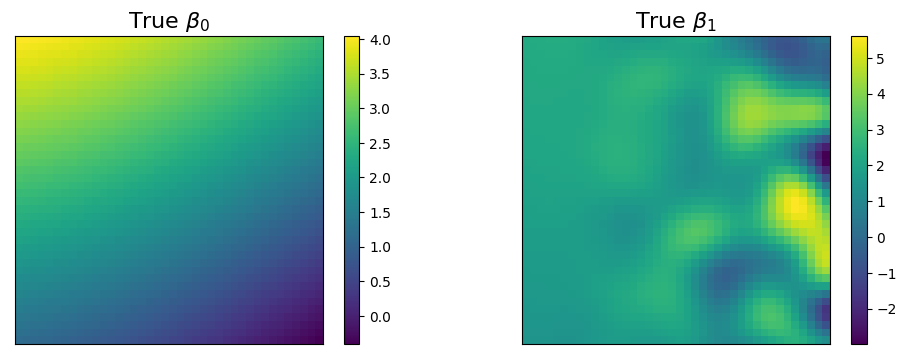

In [1]:
import numpy as np
from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW
from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

k = 1
field_size = 40
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 555],
    len_scale_seed=[100, 10]
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(
    X, beta
)

dataset.plot(
    b=np.vstack([
        beta.T
    ]),
    sub_title=[
        r"True $\beta_0$",
        r"True $\beta_1$"
    ],
    size=field_size
)

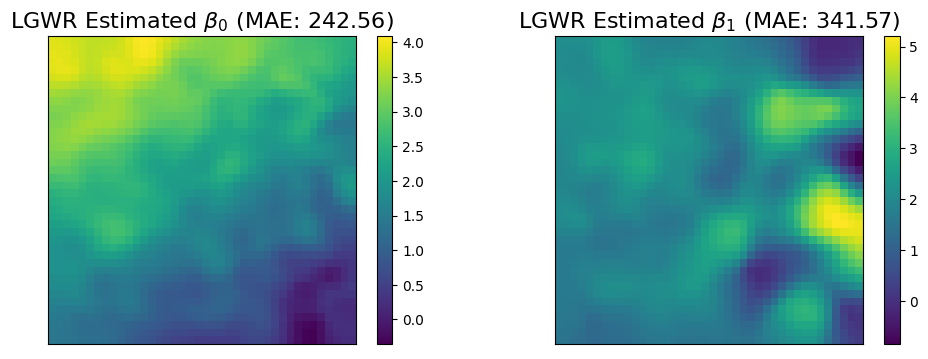

In [ ]:

global_optimal_bandwidth = 53

kernel = LgwrKernel(
    dataset,
    kernel_type='bisquare',
    kernel_bandwidth_type='adaptive'
)
lgwr = LGWR(dataset, kernel)

bw = np.full(dataset.n, global_optimal_bandwidth)
lgwr = lgwr.update_local_bandwidth_vector(
    bw
).fit()

est = np.asarray(lgwr.betas)
true = np.asarray(beta)
mae_per_coef = np.sum(np.abs(est - true), axis=0)

dataset.plot(
    b=np.vstack([
        lgwr.betas.T
    ]),
    sub_title=[
        r"LGWR Estimated $\beta_0$ (MAE: {:.2f})".format(mae_per_coef[0]),
        r"LGWR Estimated $\beta_1$ (MAE: {:.2f})".format(mae_per_coef[1])
    ],
    size=field_size
)

In [3]:
lgwr.betas

array([[3.88431023, 2.13032617],
       [3.85838319, 2.13367231],
       [3.81943913, 2.13897483],
       ...,
       [0.16171839, 0.52378967],
       [0.20713626, 0.35320941],
       [0.23085041, 0.22328282]])